# OpenCourses.AI Colab version

This notebook belongs to **Fundamentos de Transformers** and was published as a public Colab-ready artifact.

Colab is an external free execution option with variable resources. Run the setup cell before executing the rest of the notebook.


In [ ]:
# OpenCourses.AI Colab setup
import importlib, json, os, pathlib, subprocess, sys, tempfile
REPO_URL = "https://github.com/opencourses-ai-colab/opencourse-fundamentos-de-transformers-d9d23ccb.git"
BRANCH = "main"
VERSION = "56a5adfc10ebbfbc3a0ec4d850a4d82a48587607fc02a374e3201e8bc79bc7d5"
EXPECTED_SOURCE_HASH = "56a5adfc10ebbfbc3a0ec4d850a4d82a48587607fc02a374e3201e8bc79bc7d5"
REQUIRED_FILES = ["assets/audio/notebooks/01_el_problema_de_modelar_secuencias_intro.mp3","assets/audio/notebooks/02_tokens_vocabulario_y_batches_intro.mp3","assets/audio/notebooks/03_embeddings_y_geometria_de_tokens_intro.mp3","assets/audio/notebooks/04_posicion_y_orden_en_secuencias_intro.mp3","assets/audio/notebooks/05_tensores_del_transformer_intro.mp3","assets/audio/notebooks/06_atencion_como_mezcla_ponderada_intro.mp3","assets/audio/notebooks/07_queries_keys_y_values_intro.mp3","assets/audio/notebooks/08_self_attention_matricial_intro.mp3","assets/audio/notebooks/09_atencion_causal_intro.mp3","assets/audio/notebooks/10_multi_head_attention_intro.mp3","assets/audio/notebooks/11_residuales_layernorm_y_mlp_intro.mp3","assets/audio/notebooks/12_bloque_transformer_decoder_intro.mp3","assets/audio/notebooks/13_mini_gpt_desde_cero_intro.mp3","assets/audio/notebooks/14_entrenamiento_autoregresivo_intro.mp3","assets/audio/notebooks/15_generacion_interpretacion_y_limites_intro.mp3","assets/audio/notebooks/16_proyecto_final_intro.mp3","assets/audio/presentacion_curso.mp3","assets/figures/00_presentacion_del_curso.png","assets/figures/01_el_problema_de_modelar_secuencias.png","assets/figures/02_tokens_vocabulario_y_batches.png","assets/figures/03_embeddings_y_geometria_de_tokens.png","assets/figures/04_posicion_y_orden_en_secuencias.png","assets/figures/05_tensores_del_transformer.png","assets/figures/06_atencion_como_mezcla_ponderada.png","assets/figures/07_queries_keys_y_values.png","assets/figures/08_self_attention_matricial.png","assets/figures/09_atencion_causal.png","assets/figures/10_multi_head_attention.png","assets/figures/11_residuales_layernorm_y_mlp.png","assets/figures/12_bloque_transformer_decoder.png","assets/figures/13_mini_gpt_desde_cero.png","assets/figures/14_entrenamiento_autoregresivo.png","assets/figures/15_generacion_interpretacion_y_limites.png","assets/figures/16_proyecto_final.png","assets/readings/unit-10-nota-tecnica.pdf","assets/readings/unit-11-nota-tecnica.pdf","assets/readings/unit-12-nota-tecnica.pdf","assets/readings/unit-13-nota-tecnica.pdf","assets/readings/unit-14-nota-tecnica.pdf","assets/readings/unit-15-nota-tecnica.pdf","assets/readings/unit-16-nota-tecnica.pdf","assets/readings/unit-2-nota-tecnica.pdf","assets/readings/unit-3-nota-tecnica.pdf","assets/readings/unit-4-nota-tecnica.pdf","assets/readings/unit-5-nota-tecnica.pdf","assets/readings/unit-6-nota-tecnica.pdf","assets/readings/unit-7-nota-tecnica.pdf","assets/readings/unit-8-nota-tecnica.pdf","assets/readings/unit-9-nota-tecnica.pdf","notebooks/unit-1.ipynb","notebooks/unit-10.ipynb","notebooks/unit-11.ipynb","notebooks/unit-12.ipynb","notebooks/unit-13.ipynb","notebooks/unit-14.ipynb","notebooks/unit-15.ipynb","notebooks/unit-16.ipynb","notebooks/unit-17.ipynb","notebooks/unit-2.ipynb","notebooks/unit-3.ipynb","notebooks/unit-4.ipynb","notebooks/unit-5.ipynb","notebooks/unit-6.ipynb","notebooks/unit-7.ipynb","notebooks/unit-8.ipynb","notebooks/unit-9.ipynb","opencourses-colab.json","requirements.txt","src/fundamentos_transformers/__init__.py","src/fundamentos_transformers/arquitectura_experimentos.py","src/fundamentos_transformers/atencion.py","src/fundamentos_transformers/atencion_experimentos.py","src/fundamentos_transformers/componentes_interactivos.py","src/fundamentos_transformers/datos.py","src/fundamentos_transformers/embeddings.py","src/fundamentos_transformers/entrenamiento.py","src/fundamentos_transformers/entrenamiento_experimentos.py","src/fundamentos_transformers/generacion.py","src/fundamentos_transformers/generacion_experimentos.py","src/fundamentos_transformers/minigpt_experimentos.py","src/fundamentos_transformers/modelo.py","src/fundamentos_transformers/posicion.py","src/fundamentos_transformers/proyecto_final_experimentos.py","src/fundamentos_transformers/tensores.py","src/fundamentos_transformers/tokenizacion.py","src/fundamentos_transformers/visualizacion.py"]
BASE = pathlib.Path("/content/opencourses/opencourse-fundamentos-de-transformers-d9d23ccb")
BASE.mkdir(parents=True, exist_ok=True)
TARGET = BASE / VERSION
def _snapshot_issue(folder):
    if not (folder / 'notebooks').is_dir():
        return 'the notebooks folder is missing'
    missing = [name for name in REQUIRED_FILES if not (folder / name).is_file()]
    if missing:
        return 'required files are missing: ' + ', '.join(missing[:5])
    if EXPECTED_SOURCE_HASH:
        try:
            manifest = json.loads((folder / 'opencourses-colab.json').read_text(encoding='utf8'))
        except (OSError, ValueError) as error:
            return f'the publication manifest cannot be read: {error}'
        if manifest.get('source_hash') != EXPECTED_SOURCE_HASH:
            return 'the publication version has changed; reopen the latest notebook from OpenCourses.AI'
    return None
if _snapshot_issue(TARGET) is not None:
    recoveries = sorted(BASE.glob(VERSION + '-recovery-*'), key=lambda folder: folder.stat().st_mtime, reverse=True)
    existing = next((folder for folder in recoveries if _snapshot_issue(folder) is None), None)
    if existing is not None:
        TARGET = existing
    elif TARGET.exists():
        print('The course folder is incomplete. Preserving it and downloading a fresh copy.')
        TARGET = pathlib.Path(tempfile.mkdtemp(prefix=VERSION + '-recovery-', dir=BASE))
if _snapshot_issue(TARGET) is not None:
    print('Downloading the course resources...')
    try:
        subprocess.run(["git", "clone", "--depth", "1", "--branch", BRANCH, REPO_URL, str(TARGET)], check=True)
    except Exception as error:
        raise RuntimeError(f'Course download failed. Files in {TARGET} were preserved. Run setup again to retry in a fresh folder.') from error
    issue = _snapshot_issue(TARGET)
    if issue is not None:
        raise RuntimeError(f'Course setup stopped: {issue}. Files in {TARGET} were preserved; no course code was started.')
else:
    print('Using the verified folder for this course version; your local changes are preserved.')
os.environ['COURSE_ROOT'] = str(TARGET)
os.environ['ASSETS_DIR'] = str(TARGET / 'assets')
src_dir = TARGET / 'src'
if src_dir.is_dir():
    if str(src_dir) in sys.path:
        sys.path.remove(str(src_dir))
    sys.path.insert(0, str(src_dir))
importlib.invalidate_caches()
notebooks_dir = TARGET / 'notebooks'
if notebooks_dir.exists():
    os.chdir(notebooks_dir)
requirements = TARGET / 'requirements.txt'
if requirements.exists() and requirements.read_text(encoding='utf8').strip():
    print('Checking the course Python dependencies...')
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-r', str(requirements)], check=True)
try:
    from google.colab import output as colab_output
except ImportError:
    pass
else:
    try:
        colab_output.enable_custom_widget_manager()
    except Exception as error:
        print(f'Widget support could not be enabled: {error}')
print(f'COURSE_ROOT={TARGET}')
print('Setup complete. Run the remaining notebook cells from top to bottom.')


<div style="border-bottom: 2px solid #1f2a44; padding-bottom: 14px; margin-bottom: 22px;">
  <div style="display: flex; align-items: center; justify-content: space-between; gap: 24px;">
    <div style="text-align: center; flex: 1; min-width: 260px;">
      <div style="font-size: 14px; letter-spacing: 0.04em; text-transform: uppercase; color: #5b6472;">Fundamentos de Transformers</div>
      <div style="font-size: 15px; font-weight: 700; color: #667085; margin-top: 6px;">Notebook 12</div>
      <div style="font-size: 26px; font-weight: 700; color: #1f2a44; margin-top: 2px;">Bloque Transformer decoder</div>
      <div style="font-size: 14px; color: #5b6472; margin-top: 8px;">Curso abierto</div>
    </div>
  </div>
</div>

<div style="display: flex; justify-content: space-between; gap: 16px; color: #3f4754; font-size: 14px; margin-bottom: 20px; flex-wrap: wrap;">
    <div><strong>Curso:</strong> Fundamentos de Transformers</div>
  <div><strong>Periodo:</strong> 2026-I</div>
</div>


## Presentación del notebook

<audio controls style="width: 100%; margin: 8px 0 18px 0;">
  <source src="https://raw.githubusercontent.com/opencourses-ai-colab/opencourse-fundamentos-de-transformers-d9d23ccb/main/assets/audio/notebooks/12_bloque_transformer_decoder_intro.mp3" type="audio/mpeg">
  Su navegador no puede reproducir el audio embebido.
</audio>


## Pregunta directriz

> ¿Cómo se integran atención causal multi-cabeza, residuales, LayerNorm y MLP en una unidad Transformer decoder?

En los notebooks anteriores estudiamos cada pieza por separado: atención causal, atención multi-cabeza, conexiones residuales, LayerNorm y MLP. Ahora el problema es de integración: una arquitectura útil debe combinar esas piezas sin romper la interfaz tensorial.

El bloque decoder es la unidad repetible de un modelo tipo GPT. Su contrato es simple y exigente: recibe una representación con forma $(B,T,C)$, aplica mezcla contextual causal y transformación por posición, y devuelve otra representación con la misma forma.

## Objetivos

Al finalizar este notebook, el estudiante debería poder:

1. Explicar la arquitectura de un bloque Transformer decoder pre-norm.
2. Identificar qué subcapa mezcla posiciones y qué subcapa transforma canales por posición.
3. Verificar con tensores que entrada, salida y ramas residuales conservan forma $(B,T,C)$.
4. Auditar parámetros por componente: `ln1`, atención, `ln2` y MLP.
5. Interpretar un mapa de atención causal dentro del bloque sin confundirlo con una explicación semántica completa.

## Marco conceptual

Un bloque Transformer decoder no es una operación única. Es una composición de dos ramas principales: una rama de atención causal multi-cabeza y una rama MLP por posición. Cada rama se aplica sobre una versión normalizada de la representación y luego se suma de manera residual.

La rama de atención mezcla información entre posiciones permitidas. La máscara causal vive dentro de esa rama: impide que una posición consulte el futuro antes de softmax. La rama MLP no mezcla posiciones; transforma los canales de cada posición de manera independiente.

La normalización pre-norm estabiliza las entradas de cada rama. Las residuales preservan la señal previa y permiten que el bloque aprenda correcciones. La conservación de forma $(B,T,C)$ permite apilar bloques: la salida de un bloque puede entrar directamente al siguiente.

El límite conceptual es importante: ejecutar un bloque con pesos aleatorios no produce comprensión. En este notebook auditamos la arquitectura y sus invariantes; el aprendizaje aparecerá más adelante, cuando el bloque forme parte de un modelo entrenado con una pérdida autoregresiva.

## Mapa visual del notebook

La figura resume el patrón del bloque decoder pre-norm: `LN1`, atención causal multi-cabeza, residual, `LN2`, MLP por posición y una segunda residual. Lo importante es que cada rama devuelve una corrección compatible con $(B,T,C)$.

<div style="text-align: center; margin: 12px 0 18px 0;">
  <img src="https://raw.githubusercontent.com/opencourses-ai-colab/opencourse-fundamentos-de-transformers-d9d23ccb/main/assets/figures/12_bloque_transformer_decoder.png" alt="Bloque Transformer decoder" style="width: min(980px, 98%); height: auto; border: 1px solid #d0d7de; border-radius: 6px;">
</div>

La lectura correcta es de interfaz y de responsabilidades: atención mezcla posiciones, MLP transforma canales, LayerNorm prepara cada rama y las residuales hacen que el bloque pueda apilarse sin cambiar el contrato $(B,T,C)$.

## Formulación matemática

Sea $X \in \mathbb{R}^{B \times T \times C}$ la entrada del bloque. En una versión pre-norm, la primera rama es:

$$
U = X + \operatorname{MHA}_{causal}(\operatorname{LN}_1(X)).
$$

Esta ecuación se lee así: se normaliza $X$, se aplica atención causal multi-cabeza y la salida de esa rama se suma con la entrada original. La rama de atención es la única que mezcla posiciones sobre el eje $T$.

La segunda rama es:

$$
Y = U + \operatorname{MLP}(\operatorname{LN}_2(U)).
$$

Esta ecuación se lee así: se normaliza el estado intermedio $U$, se transforma cada posición con una MLP sobre canales $C$ y se suma esa corrección al propio $U$.

La traza completa del bloque es:

$$
X \rightarrow \operatorname{LN}_1(X) \rightarrow \operatorname{MHA}_{causal} \rightarrow U = X + \operatorname{MHA}_{causal}(\operatorname{LN}_1(X)) \rightarrow \operatorname{LN}_2(U) \rightarrow \operatorname{MLP} \rightarrow Y = U + \operatorname{MLP}(\operatorname{LN}_2(U)).
$$

Esta ecuación se lee así: el bloque abre dos ramas pre-norm; cada rama calcula una corrección, y cada residual exige que la corrección tenga la misma forma que el estado que se suma.

Si apilamos bloques, la capa $\ell$ cumple:

$$
Z^{\ell+1}=\operatorname{Block}_{\ell}(Z^{\ell}),
\qquad
Z^{\ell},Z^{\ell+1}\in\mathbb{R}^{B\times T\times C}.
$$

Esta ecuación se lee así: cada bloque recibe y devuelve el mismo tipo de tensor, aunque su contenido representacional cambie. Usamos $Z^\ell$ para el estado de la capa y evitamos confundirlo con el número de cabezas.

La condición de multi-cabeza sigue vigente:

$$
C = n_h \cdot D,
$$

donde $n_h$ es el número de cabezas y $D$ los canales por cabeza. Esta relación permite reorganizar $Q$, $K$ y $V$ como $(B,n_h,T,D)$ dentro de la subcapa de atención.

## Traducción tensorial

| Etapa | Forma | Eje que opera | Interpretación |
|---|---:|---|---|
| Entrada $X$ | $(B,T,C)$ | - | representación recibida por el bloque |
| $\operatorname{LN}_1(X)$ | $(B,T,C)$ | $C$ | normalización por posición antes de atención |
| Atención causal multi-cabeza | $(B,T,C)$ | $T$ y $C=H\cdot D$ | mezcla posiciones permitidas y recompone canales |
| Residual 1 | $(B,T,C)$ | $(B,T,C)$ | $X$ más corrección contextual |
| $\operatorname{LN}_2(U)$ | $(B,T,C)$ | $C$ | normalización antes de MLP |
| MLP por posición | $(B,T,C)$ | $C$ | transformación local de canales |
| Residual 2 | $(B,T,C)$ | $(B,T,C)$ | salida apilable del bloque |

El bloque cambia el contenido de las representaciones, pero no cambia su interfaz. Esa es la razón por la que puede repetirse muchas veces.

## Preparación del entorno

In [1]:
from pathlib import Path
import importlib
import sys
import warnings

from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import torch

warnings.filterwarnings("ignore", message="Pandas requires version .*", category=UserWarning)
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import fundamentos_transformers.arquitectura_experimentos as arquitectura_experimentos
import fundamentos_transformers.componentes_interactivos as componentes_interactivos
import fundamentos_transformers.visualizacion as visualizacion

arquitectura_experimentos = importlib.reload(arquitectura_experimentos)
componentes_interactivos = importlib.reload(componentes_interactivos)
visualizacion = importlib.reload(visualizacion)

crear_explorador_bloque_decoder = componentes_interactivos.crear_explorador_bloque_decoder
configurar_matplotlib = visualizacion.configurar_matplotlib
mostrar_tablas_en_columnas = visualizacion.mostrar_tablas_en_columnas

configurar_matplotlib()
torch.manual_seed(7)
np.random.seed(7)


## Experimento mínimo

Instanciaremos un bloque decoder mínimo con `dropout=0.0`. Ese detalle es deliberado: cuando queremos leer una matriz de atención como distribución, desactivar dropout evita que se modifiquen los pesos después de softmax y permite verificar que cada fila suma 1.

En lugar de tratar `TransformerBlock` como caja negra, abriremos su traza interna usando `ln1`, `attn`, `ln2` y `ffwd`. Auditaremos:

1. forma interna de cada etapa;
2. parámetros por componente;
3. restricción causal dentro de la atención;
4. compatibilidad de la salida para apilar otro bloque.

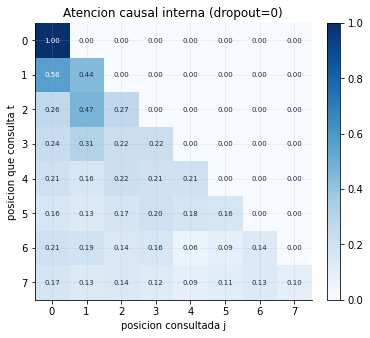

In [2]:
resultado_bloque = arquitectura_experimentos.preparar_bloque_decoder(seed=7)

mostrar_tablas_en_columnas(
    [
        ("Auditoría interna", resultado_bloque.traza),
        ("Parámetros", resultado_bloque.parametros),
        ("Verificaciones", resultado_bloque.verificaciones),
        ("Fila de atención t=5", resultado_bloque.fila_atencion),
    ],
    min_width="320px",
)


La auditoría confirma el contrato central: el bloque puede modificar las representaciones, pero conserva la forma externa en `X`, `U` y `Y`. También abre el bloque por dentro: `LN1` prepara atención, la MHA mezcla posiciones, `LN2` prepara la MLP y la MLP transforma canales por posición.

Como usamos `dropout=0.0`, los pesos de atención devueltos son legibles como distribuciones: las filas suman 1 y la masa futura es 0.

## Visualización de atención interna

Visualizaremos la primera cabeza del primer ejemplo. La matriz no debe interpretarse como explicación semántica completa; solo muestra qué posiciones fueron mezcladas bajo esta inicialización. En este experimento el dropout está desactivado para facilitar la lectura de las filas de atención.

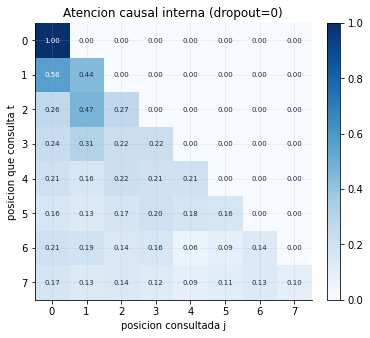

In [3]:
display(resultado_bloque.figura)
plt.close(resultado_bloque.figura)


## Explorador interactivo

El explorador permite cambiar $C$, $H$ y $T$ para observar cuándo el bloque es válido, cómo cambian los parámetros, qué forma tienen los pesos de atención y cómo se abre la traza interna `LN1 -> MHA -> residual -> LN2 -> MLP -> residual`.

In [4]:
crear_explorador_bloque_decoder()

## Verificación de aprendizaje

Modifica el explorador y responde con evidencia:

1. Elige una configuración válida. Reporta $C$, $H$, $D$ y la forma de los pesos $A$.
2. Elige una configuración inválida. Explica por qué no se puede separar la atención en cabezas.
3. Mantén $C$ fijo y cambia $H$. ¿Qué ocurre con $D$ y con la forma de $A$?
4. En la traza interna, identifica qué paso mezcla posiciones $T$ y qué paso transforma canales $C$ por posición.
5. Identifica qué componentes tienen parámetros y cuáles no aparecen como parámetros aprendibles directos.
6. Explica por qué conservar $(B,T,C)$ en `X`, `U` y `Y` permite apilar bloques.
7. Usa la fila de atención para verificar que el futuro queda bloqueado y explica por qué eso no prueba comprensión lingüística.
8. Explica por qué usamos `dropout=0.0` cuando queremos auditar filas de atención como distribuciones.

## Análisis crítico

El experimento muestra que el bloque decoder integra cuatro ideas: atención causal multi-cabeza, normalización pre-norm, suma residual y MLP por posición. Cada pieza cumple una función distinta y todas respetan el contrato tensorial.

La atención es la única subcapa que mezcla posiciones. La MLP transforma canales dentro de cada posición. LayerNorm estabiliza las entradas de las ramas y las residuales acumulan correcciones sin destruir la señal previa. La traza interna evita que el bloque se convierta en una caja negra después de haber estudiado sus piezas por separado.

El detalle `dropout=0.0` no es una afirmación sobre entrenamiento real; es una decisión pedagógica. Si activáramos dropout sobre los pesos de atención, la matriz devuelta ya no sería tan limpia para verificar filas que suman 1.

El límite de esta evidencia es que el bloque no está entrenado. Ver una matriz causal correcta y una salida con forma válida no significa que el modelo haya aprendido lenguaje. Significa que la arquitectura está bien construida para ser usada en un modelo entrenable.

## Síntesis

La cadena operacional del notebook es:

$$
X \rightarrow \operatorname{LN}_1(X) \rightarrow \operatorname{MHA}_{causal} \rightarrow U = X + \operatorname{MHA}_{causal}(\operatorname{LN}_1(X)) \rightarrow \operatorname{LN}_2(U) \rightarrow \operatorname{MLP} \rightarrow Y = U + \operatorname{MLP}(\operatorname{LN}_2(U)).
$$

Esta cadena se lee así: el bloque normaliza, mezcla contexto con atención causal, suma residual, normaliza de nuevo, transforma canales con MLP y vuelve a sumar para producir una salida compatible.

<div style="border-left: 4px solid #1f2a44; padding: 10px 14px; background: #f6f8fa; margin-top: 10px;">
La idea central es que un bloque decoder es una unidad apilable: cambia la representación interna sin cambiar el contrato tensorial de entrada y salida.
</div>

## Preguntas de discusión

1. ¿Qué parte del bloque mezcla posiciones y qué parte transforma canales por posición?
2. ¿Por qué la máscara causal pertenece a la subcapa de atención y no a la MLP?
3. ¿Por qué las residuales obligan a que las ramas devuelvan forma $(B,T,C)$?
4. ¿Qué información aporta el conteo de parámetros por componente?
5. ¿Qué no se puede concluir al ejecutar un bloque decoder con pesos aleatorios?

## Continuidad

Ya tenemos una unidad decoder funcional. El siguiente paso es construir un modelo completo: embeddings de tokens, embeddings posicionales, varios bloques decoder, normalización final y una cabeza de lenguaje.

El notebook 13 integra estos elementos en un mini GPT desde cero.